# Data description

In [1]:

import os
import sys
import importlib
from importlib import reload 
from dataclasses import dataclass, field, fields
from itertools import compress
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

import scipy
import scipy.io as sio
from scipy import signal
from scipy.signal import spectrogram, hann, butter, filtfilt, freqz
from scipy import stats
from scipy.stats import norm
from scipy.stats import ttest_ind

import seaborn as sns
import pingouin as pg
import itertools
from itertools import combinations
from statannotations.Annotator import Annotator
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices
import plotly.express as px

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report

# import openpyxl
# from openpyxl import Workbook, load_workbook
# import xlrd
import pickle
import json
import csv

#mne
import mne_bids
import mne
from mne.time_frequency import tfr_morlet 
from mne.stats import permutation_cluster_test


# TODO: add README file: 
# pip install pingouin
# pip install statannotations
# pip install fooof

/Users/jenniferbehnke/anaconda3/envs/bssu/lib/python3.11/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [5]:
jennifer_user_path = os.getcwd()
while jennifer_user_path[-14:] != 'jenniferbehnke':
    jennifer_user_path = os.path.dirname(jennifer_user_path)

# directory to this Repository
project_path = os.path.join(jennifer_user_path, 'code', 'BetaSenSightLongterm', 'BetaSenSightLongterm')
sys.path.append(project_path)

os.chdir(project_path)

import src.bssu.utils.find_folders as find_folders
importlib.reload(find_folders)

# import PyPerceive

project_path = find_folders.chdir_repository("Py_Perceive")

from PerceiveImport.classes import (
    main_class, modality_class, metadata_class,
    session_class, condition_class, task_class,
    contact_class, run_class
)

import PerceiveImport.methods.load_rawfile as load_rawfile
import PerceiveImport.methods.find_folders as PyPerceive_find_folders
import PerceiveImport.methods.metadata_helpers as metaHelpers

# import meet

project_path = find_folders.chdir_repository("meet")

import meet as meet

# import all functions from BetaSenSightLongterm
project_path = find_folders.chdir_repository("BetaSenSightLongterm")

# tfr, processing
import src.bssu.tfr.BSSuPsd as BSSuPsd
import src.bssu.tfr.FastFourierPSD as FFpsd
import src.bssu.tfr.fooof_fit as fooof_fit

# bipolar Channel Analysis
import src.bssu.bipolar.power_spectra_plots as power_spectra_plots
import src.bssu.bipolar.PeakFrequencies_PSD as PeakFrequency_psd
import src.bssu.bipolar.BIP_channelGroups as BIP_channelGroups
import src.bssu.bipolar.BIP_perChannelAnalysis as BIP_perChannel


# monopolar Referencing
import src.bssu.monopolar.MonoRef_JLB as MonoRefJLB
import src.bssu.monopolar.GroupMonopolarPSD as groupMonopol
import src.bssu.monopolar.monoRef_weightPsdAverageByCoordinateDistance as MonoRefWeightedCoordinateDistance
import src.bssu.monopolar.externalized_lfp as externalized
import src.bssu.monopolar.monopol_method_comparison as monopol_comparison
import src.bssu.monopolar.bssu_contacts_maximal_beta as bssu_contacts
import src.bssu.monopolar.monoRef_Strelow as detec_strelow

# Ranking Order
import src.bssu.ranking.HighestRankedChannelPSD as highestRank
import src.bssu.ranking.monopolPSDaverage_withinSubject as PSDaverageMonopol
import src.bssu.ranking.BIPchannelGroups_ranks as BIP_ranks
import src.bssu.ranking.Permutation_rankings as Permute_ranks
import src.bssu.ranking.beta_rank_longitudinal_changes as beta_rank_change


# Clinical stimulation parameters
import src.bssu.stimulation.activeStimulationContacts as activeStimContacts

# utility functions
import src.bssu.utils.loadResults as loadResults
import src.bssu.utils.find_folders as find_folders
import src.bssu.utils.writeGroupDataframes as writeGroupDF
import src.bssu.utils.load_data_files as load_data
import src.bssu.utils.monopol_comparison_helpers as mono_comp_helpers
import src.bssu.utils.sub_session_dict as sub_session_dict
import src.bssu.utils.percept_helpers as helpers
# import Classes
from src.bssu.classes import (metadataAnalysis_class, mainAnalysis_class, sessionAnalysis_class, 
                              channelAnalysis_class, featureAnalysis_class, frequencyBand_class)

# import mni coordinates
import src.bssu.mni.load_rotated_coordinates as load_mni


importlib.reload(BSSuPsd)
importlib.reload(MonoRefJLB)
importlib.reload(loadResults)
importlib.reload(highestRank)
importlib.reload(groupMonopol)
importlib.reload(PSDaverageMonopol)
importlib.reload(FFpsd)
importlib.reload(find_folders)
importlib.reload(metadataAnalysis_class)
importlib.reload(mainAnalysis_class)
importlib.reload(sessionAnalysis_class)
importlib.reload(channelAnalysis_class)
importlib.reload(featureAnalysis_class)
importlib.reload(frequencyBand_class)
importlib.reload(PeakFrequency_psd)
importlib.reload(power_spectra_plots)
importlib.reload(BIP_channelGroups)
importlib.reload(BIP_ranks)
importlib.reload(activeStimContacts)
importlib.reload(Permute_ranks)
importlib.reload(BIP_perChannel)
importlib.reload(load_mni)
importlib.reload(writeGroupDF)
importlib.reload(MonoRefWeightedCoordinateDistance)
importlib.reload(load_data)
importlib.reload(externalized)
importlib.reload(monopol_comparison)
importlib.reload(bssu_contacts)
importlib.reload(mono_comp_helpers)
importlib.reload(detec_strelow)
importlib.reload(beta_rank_change)
importlib.reload(sub_session_dict)
importlib.reload(helpers)
importlib.reload(fooof_fit)

Excel file loaded:  patient_metadata.xlsx 
loaded from:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/Monopolar_power_estimation/data


<module 'src.bssu.tfr.fooof_fit' from '/Users/jenniferbehnke/code/BetaSenSightLongterm/BetaSenSightLongterm/src/bssu/tfr/fooof_fit.py'>

In [90]:
# load if you want to see complete Dataframes
pd.set_option("display.max_rows", None)

## Steps to write data

In [ ]:
# add single fooof results to group fooof results
# fooof_all_subjects = fooof_fit.add_fooof_singles_to_group_data(sub_list=["017", "026", "040", "059", "060", 
#                                                                          "066", "069", "072",
#                                                                          "075", "081", "084"], 
#                                                                 fooof_version="v2")



In [ ]:
loaded_fooof_result = loadResults.load_pickle_group_result(filename="fooof_group_data_percept", fooof_version="v2")
loaded_fooof_result.loc[loaded_fooof_result["subject_hemisphere"] == "026_Right"]

In [ ]:
# load the pickle FOOOF group dataframe
# calculate beta average
# rank beta within a channel group

# ranked_beta_fooof_group_percept = fooof_fit.highest_beta_channels_fooof_percept(
#     fooof_spectrum="periodic_spectrum",
#     fooof_version="v2"
# )

In [ ]:
beta_rank_DF = loadResults.load_fooof_beta_ranks(
        fooof_spectrum="periodic_spectrum",
        fooof_version="v2",
        all_or_one_chan="beta_ranks_all",
        all_or_one_longterm_ses="one_longterm_session",
    )

beta_rank_DF.head()

## Load finalized FOOOF data

### FOOOF data per group

In [15]:
# FOOOF data of all channels (15 channels per STN)

beta_rank_DF = loadResults.load_fooof_beta_ranks(
        fooof_spectrum="periodic_spectrum",
        fooof_version="v2",
        all_or_one_chan="beta_all",
        all_or_one_longterm_ses="one_longterm_session",
    )

beta_rank_DF.head()

,subject_hemisphere,session,bipolar_channel,fooof_error,fooof_r_sq,fooof_exponent,fooof_offset,fooof_power_spectrum,periodic_plus_aperiodic_power_log,fooof_periodic_flat,fooof_number_peaks,alpha_peak_CF_power_bandWidth,low_beta_peak_CF_power_bandWidth,high_beta_peak_CF_power_bandWidth,beta_peak_CF_power_bandWidth,gamma_peak_CF_power_bandWidth,beta_average
0,017_Right,fu3m,03,0.066416,0.98557,1.688615,1.332174,"[0.00767014426514212, 0.03351470878412366, 0.1...","[0.8243496620189412, 0.5308087522174064, 0.339...","[0.0004994452423981573, 0.004308872706144536, ...",4,"[nan, nan, nan]","[nan, nan, nan]","[28.987529527052935, 0.5952799100446403, 7.519...","[28.987529527052935, 0.5952799100446403, 7.519...","[nan, nan, nan]",0.073489
1,017_Right,fu3m,13,0.088264,0.96624,1.457102,1.030205,"[0.008159401337378469, 0.006371132823893344, 0...","[0.5924797149155441, 0.33626772579620084, 0.15...","[0.0009066008320197118, 0.0012775321970460254,...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.225692476850114, 0.9213419411183563, 3.000...","[29.225692476850114, 0.9213419411183563, 3.000...","[nan, nan, nan]",0.150319
2,017_Right,fu3m,02,0.093521,0.971951,1.685157,1.420904,"[7.787614109133756e-09, 1.882592837176844e-08,...","[0.9136209432416069, 0.6168795782504854, 0.406...","[4.126367042459155e-10, 1.975427741277798e-09,...",3,"[nan, nan, nan]","[nan, nan, nan]","[29.073003972962415, 0.9881124104459198, 8.238...","[29.073003972962415, 0.9881124104459198, 8.238...","[nan, nan, nan]",0.254790
3,017_Right,fu3m,12,0.07857,0.972904,1.343522,0.757904,"[0.0003292927862230677, 0.0003079802974601531,...","[0.35352735458664525, 0.11698373243642358, -0....","[6.336812502902425e-05, 0.00010218204803303865...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.43438184459086, 1.099716477148555, 4.71406...","[29.43438184459086, 1.099716477148555, 4.71406...","[nan, nan, nan]",0.204537
4,017_Right,fu3m,01,0.071117,0.979469,1.587926,1.157176,"[0.0260612717972748, 0.08068602780119916, 0.20...","[0.6815260508032184, 0.4132884933120965, 0.253...","[0.0023628423792285266, 0.01374512167041695, 0...",4,"[nan, nan, nan]","[nan, nan, nan]","[33.50000000000001, 0.34359567811682745, 3.000...","[33.50000000000001, 0.34359567811682745, 3.000...","[64.15854737876835, 0.19383025351969008, 10.73...",0.030401


In [16]:
beta_rank_DF.columns

Index(['subject_hemisphere', 'session', 'bipolar_channel', 'fooof_error',
       'fooof_r_sq', 'fooof_exponent', 'fooof_offset', 'fooof_power_spectrum',
       'periodic_plus_aperiodic_power_log', 'fooof_periodic_flat',
       'fooof_number_peaks', 'alpha_peak_CF_power_bandWidth',
       'low_beta_peak_CF_power_bandWidth', 'high_beta_peak_CF_power_bandWidth',
       'beta_peak_CF_power_bandWidth', 'gamma_peak_CF_power_bandWidth',
       'beta_average'],
      dtype='object')

Data description of all included FOOOF channels

In [6]:
### data description
def data_description(dataset:str, cohort:str):
    """
    Data description of FOOOF data
    """
    selected_fooof_data = loadResults.select_fooof_data(dataset=dataset,cohort=cohort)
    selected_fooof_data = selected_fooof_data["fooof_data"]

    # list of subjects
    subjects = list(selected_fooof_data.subject_hemisphere.str.split("_").str[0].unique())
    sub_hem_list = list(selected_fooof_data.subject_hemisphere.unique())

    print(
        f"Number of channels fitted: {len(selected_fooof_data.subject_hemisphere.values)}"
    )
    print(f"List of STNs: {list(selected_fooof_data.subject_hemisphere.unique())}")
    print(
        f"Number of STNs: {len(selected_fooof_data.subject_hemisphere.unique())}",
        "\nNumber of patients: "
        + (str(len(selected_fooof_data.subject_hemisphere.unique()) / 2)),
    )

    # mean, std, sem of fooof error and r squared
    mean_fooof_error = np.mean(selected_fooof_data["fooof_error"])
    std_fooof_error = np.std(selected_fooof_data["fooof_error"])
    sem_fooof_error = stats.sem(selected_fooof_data["fooof_error"])

    mean_fooof_r_sq = np.mean(selected_fooof_data["fooof_r_sq"])
    std_fooof_r_sq = np.std(selected_fooof_data["fooof_r_sq"])
    sem_fooof_r_sq = stats.sem(selected_fooof_data["fooof_r_sq"])

    print(f"FOOOF error mean: {mean_fooof_error},",
        f"\nFOOOF error standard deviation: {std_fooof_error},",
        f"\nFOOOF error sem: {sem_fooof_error},",

        f"\n\nFOOOF r squared mean: {mean_fooof_r_sq}",
        f"\nFOOOF r squared standard deviation: {std_fooof_r_sq},",
        f"\nFOOOF r squared sem: {sem_fooof_r_sq}")
    
    return {
        "subjects": subjects,
        "sub_hem_list": sub_hem_list,
        "selected_fooof_data": selected_fooof_data
    }

In [7]:
data = data_description(dataset="bipolar_beta", cohort="all_included")


Number of channels fitted: 2256
List of STNs: ['017_Right', '017_Left', '019_Right', '019_Left', '021_Right', '021_Left', '024_Right', '024_Left', '025_Right', '025_Left', '026_Right', '026_Left', '028_Right', '028_Left', '029_Right', '029_Left', '030_Right', '030_Left', '031_Right', '031_Left', '032_Right', '032_Left', '033_Right', '033_Left', '038_Right', '038_Left', '040_Right', '040_Left', '041_Right', '041_Left', '047_Right', '047_Left', '048_Right', '048_Left', '049_Right', '049_Left', '050_Right', '050_Left', '052_Right', '052_Left', '055_Right', '055_Left', '059_Right', '059_Left', '060_Right', '060_Left', '061_Right', '061_Left', '062_Right', '062_Left', '063_Right', '063_Left', '065_Right', '065_Left', '066_Right', '066_Left', '069_Right', '069_Left', '072_Right', '072_Left', '075_Right', '075_Left', '081_Right', '081_Left', '084_Right', '084_Left']
Number of STNs: 66 
Number of patients: 33.0
FOOOF error mean: 0.07598513453206487, 
FOOOF error standard deviation: 0.012971228

In [174]:
data["selected_fooof_data"].head()

,index,subject_hemisphere,session,bipolar_channel,fooof_error,fooof_r_sq,fooof_exponent,fooof_offset,fooof_power_spectrum,periodic_plus_aperiodic_power_log,fooof_periodic_flat,fooof_number_peaks,alpha_peak_CF_power_bandWidth,low_beta_peak_CF_power_bandWidth,high_beta_peak_CF_power_bandWidth,beta_peak_CF_power_bandWidth,gamma_peak_CF_power_bandWidth,beta_average,beta_rank,subject
0,3,017_Right,fu3m,12,0.07857,0.972904,1.343522,0.757904,"[0.0003292927862230677, 0.0003079802974601531,...","[0.35352735458664525, 0.11698373243642358, -0....","[6.336812502902425e-05, 0.00010218204803303865...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.43438184459086, 1.099716477148555, 4.71406...","[29.43438184459086, 1.099716477148555, 4.71406...","[nan, nan, nan]",0.204537,1.0,017
0,12,017_Right,fu3m,1A2A,0.086413,0.969713,1.477671,1.203942,"[1.051259040174557e-05, 9.481947880196628e-06,...","[0.7591189582797522, 0.4989144774934115, 0.314...","[7.950153134128949e-07, 1.3054734695782597e-06...",3,"[nan, nan, nan]","[nan, nan, nan]","[30.823647968559502, 1.0136923869600145, 7.425...","[30.823647968559502, 1.0136923869600145, 7.425...","[nan, nan, nan]",0.277904,1.0,017
5,11,017_Right,fu3m,2A2C,0.070059,0.975923,1.279358,0.622745,"[1.3979065716096528e-06, 2.5015002960149246e-0...","[0.2376206914896252, 0.01233768192489373, -0.1...","[3.512707128119114e-07, 1.0559606045368374e-06...",4,"[nan, nan, nan]","[13.59303036339205, 0.12463061825765231, 3.000...","[28.344306091350532, 0.9307513411542273, 9.686...","[28.344306091350532, 0.9307513411542273, 9.686...","[nan, nan, nan]",0.172262,1.0,017
2,20,017_Right,fu12m,23,0.064378,0.989523,1.700796,1.440666,"[2.6991400101650243e-05, 5.4799935694127555e-0...","[0.9286766131841131, 0.6291855485581883, 0.416...","[1.3814456454305008e-06, 5.589611276521289e-06...",4,"[nan, nan, nan]","[13.805828105459103, 0.7460678514380996, 3.064...","[28.513423058870664, 0.9111804619360752, 5.374...","[28.513423058870664, 0.9111804619360752, 5.374...","[nan, nan, nan]",0.516692,1.0,017
0,27,017_Right,fu12m,1A2A,0.054754,0.98773,1.600978,1.328914,"[0.0011917227674977937, 0.0012032524253271504,...","[0.8470456604000512, 0.5651960382547497, 0.365...","[7.36123518097955e-05, 0.00014223816337737217,...",4,"[nan, nan, nan]","[nan, nan, nan]","[27.185455000237216, 0.41889408694839625, 12.0...","[27.185455000237216, 0.41889408694839625, 12.0...","[63.12950075977409, 0.2016035648850072, 3.0000...",0.111572,1.0,017


In [221]:
# how many channels have identified a peak in low beta, high beta or beta
# Function to count lists with floats for each column
def count_identified_peaks(beta_range_column: pd.Series):
    return sum(isinstance(row, np.ndarray) and not np.all(np.isnan(row)) for row in beta_range_column)

def count_identified_double_peaks(fooof_data: pd.DataFrame):
    peak_results = {
        "subject_hemisphere": [],
        "session": [],
        "bipolar_channel": [],
        "low_beta_peak_CF": [],
        "low_beta_peak_power": [],
        "high_beta_peak_CF": [],
        "high_beta_peak_power": []
    }
    
    for row in fooof_data.iterrows():
        if isinstance(row[1]["low_beta_peak_CF_power_bandWidth"], np.ndarray) and not np.all(np.isnan(row[1]["low_beta_peak_CF_power_bandWidth"])) and isinstance(row[1]["high_beta_peak_CF_power_bandWidth"], np.ndarray) and not np.all(np.isnan(row[1]["high_beta_peak_CF_power_bandWidth"])):
            # append to dictionary if there is a peak in both columns
            peak_results["subject_hemisphere"].append(row[1]["subject_hemisphere"])
            peak_results["session"].append(row[1]["session"])
            peak_results["bipolar_channel"].append(row[1]["bipolar_channel"])
            peak_results["low_beta_peak_CF"].append(row[1]["low_beta_peak_CF_power_bandWidth"][0])
            peak_results["low_beta_peak_power"].append(row[1]["low_beta_peak_CF_power_bandWidth"][1])
            peak_results["high_beta_peak_CF"].append(row[1]["high_beta_peak_CF_power_bandWidth"][0])
            peak_results["high_beta_peak_power"].append(row[1]["high_beta_peak_CF_power_bandWidth"][1])
    
    return pd.DataFrame(peak_results), len(peak_results["subject_hemisphere"])

# count identified peaks only if there is a peak in both columns



In [ ]:
selected_fooof_data = loadResults.select_fooof_data(dataset="bipolar_beta", cohort="all_included",)
selected_fooof_data = selected_fooof_data["fooof_data"]

double_peaks = count_identified_double_peaks(selected_fooof_data)
double_peaks[1]

303

In [234]:
def bar_plot_number_of_peaks(dataset:str, cohort:str, channel_group:str, session:str):
    """
    Bar plot of number of channels with identified peaks in low beta, high beta, beta

    Input:
        - dataset: str, "bipolar_beta", "bipolar_highest_beta" (only rank 1 channels per channel group)
        - cohort: str, "all_included", "group_1", "group_2", "group_3"
        - channel_group: str, "ring", "segm_inter", "segm_intra", "all_channels"
        - session: str, "fu3m", "all_sessions"
    """

    figures_path = find_folders.get_local_path(folder="GroupFigures")

    selected_fooof_data = loadResults.select_fooof_data(dataset=dataset,cohort=cohort)
    selected_fooof_data = selected_fooof_data["fooof_data"]

    # select for correct channel group
    if channel_group in {"ring", "segm_inter", "segm_intra"}:
        channel_group_dict = {"ring": ["01", "12", "23"],
                              "segm_inter": ["1A2A", "1B2B", "1C2C"],
                              "segm_intra": ["1A1B", "1A1C", "1B1C", "2A2B", "2A2C", "2B2C"]}

        selected_fooof_data = selected_fooof_data.loc[selected_fooof_data["bipolar_channel"].isin(channel_group_dict[channel_group])]

    else: 
        selected_fooof_data = selected_fooof_data
    
    # select for correct session
    if session in ["fu3m", "postop", "fu12m", "fu18or24m"]:
        selected_fooof_data = selected_fooof_data.loc[selected_fooof_data["session"] == session]
    
    else:
        selected_fooof_data = selected_fooof_data


    # count number of channels with identified peaks in low beta, high beta, beta
    low_beta_peaks = count_identified_peaks(selected_fooof_data["low_beta_peak_CF_power_bandWidth"])
    high_beta_peaks = count_identified_peaks(selected_fooof_data["high_beta_peak_CF_power_bandWidth"])
    beta_peaks = count_identified_peaks(selected_fooof_data["beta_peak_CF_power_bandWidth"])
    double_beta_peaks = count_identified_double_peaks(selected_fooof_data)[1]

    # count number of channels in the column
    total_channels = len(selected_fooof_data)

    # percentage of channels with identified peaks
    low_beta_peaks_percentage = (low_beta_peaks / total_channels) * 100
    high_beta_peaks_percentage = (high_beta_peaks / total_channels) * 100
    beta_peaks_percentage = (beta_peaks / total_channels) * 100
    double_peaks_percentage = (double_beta_peaks / total_channels) * 100

    # create a bar plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(
        ["Low Beta", "High Beta", "Beta", "Double Beta Peaks"],
        [low_beta_peaks_percentage, high_beta_peaks_percentage, beta_peaks_percentage, double_peaks_percentage],
        width=0.5,
        #color=["#1f77b4", "#ff7f0e", "#2ca02c"],
    )
    # # add numbers of channels with identified peaks at the top of the bars
    # for i, v in enumerate([low_beta_peaks, high_beta_peaks, beta_peaks]):
    #     ax.text(i, v, str(v), ha="center", va="bottom")

    ax.set_ylabel("Percentage of channels with identified peaks [%]")
    ax.set_title("Percentage of channels with identified peaks in low beta, high beta, beta")
    fig.tight_layout()

    fig.savefig(
            os.path.join(
                figures_path,
                f"revision_{cohort}_{dataset}_peak_numbers_barplot.png",
            ),
            bbox_inches="tight",
        )

    fig.savefig(
        os.path.join(
            figures_path,
            f"revision_{cohort}_{dataset}_peak_numbers_barplot.svg",
        ),
        bbox_inches="tight",
        format="svg",
    )

    print(f"low beta: {low_beta_peaks}",
    f"\nhigh beta: {high_beta_peaks}",
    f"\nbeta: {beta_peaks}",
    f"\ndouble beta peaks: {double_beta_peaks}"
    f"\ntotal channels: {total_channels}",
    f"\nlow beta percentage: {low_beta_peaks_percentage}",
    f"\nhigh beta percentage: {high_beta_peaks_percentage}",
    f"\nbeta percentage: {beta_peaks_percentage}",
    f"\ndouble beta peaks percentage: {double_peaks_percentage}")
    

    return {
        "low_beta_peaks": low_beta_peaks,
        "high_beta_peaks": high_beta_peaks,
        "beta_peaks": beta_peaks,
        "double_beta_peaks": double_beta_peaks,
        "total_channels": total_channels,
        "low_beta_peaks_percentage": low_beta_peaks_percentage,
        "high_beta_peaks_percentage": high_beta_peaks_percentage,
        "beta_peaks_percentage": beta_peaks_percentage,
        "double_beta_peaks_percentage": double_peaks_percentage,
    }

    

low beta: 35 
high beta: 46 
beta: 46 
double beta peaks: 35
total channels: 46 
low beta percentage: 76.08695652173914 
high beta percentage: 100.0 
beta percentage: 100.0 
double beta peaks percentage: 76.08695652173914


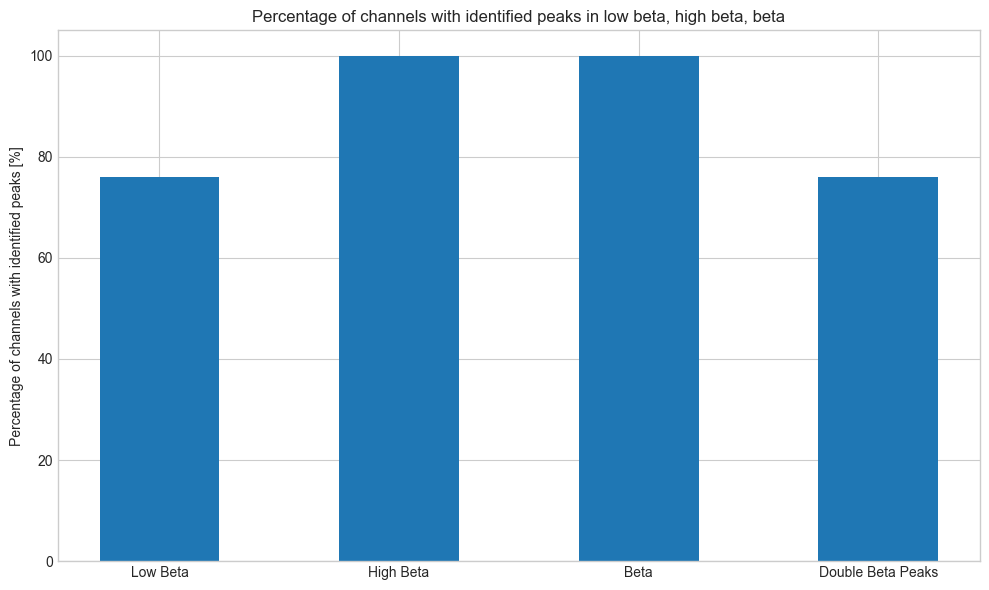

In [237]:
bar_plot = bar_plot_number_of_peaks(dataset="bipolar_highest_beta", cohort="all_included", channel_group="ring", session="fu3m")

### BIPOLAR

In [23]:
# FOOOF data only of one longterm session
# 12 LFP channels per STN

selected_fooof_data = loadResults.select_fooof_data(data="bipolar_beta",cohort="all_included")

# beta_rank_DF = loadResults.load_fooof_beta_ranks(
#         fooof_spectrum="periodic_spectrum",
#         fooof_version="v2",
#         all_or_one_chan="beta_ranks_all",
#         all_or_one_longterm_ses="one_longterm_session",
#     )

selected_fooof_data["fooof_data"]

,index,subject_hemisphere,session,bipolar_channel,fooof_error,fooof_r_sq,fooof_exponent,fooof_offset,fooof_power_spectrum,periodic_plus_aperiodic_power_log,fooof_periodic_flat,fooof_number_peaks,alpha_peak_CF_power_bandWidth,low_beta_peak_CF_power_bandWidth,high_beta_peak_CF_power_bandWidth,beta_peak_CF_power_bandWidth,gamma_peak_CF_power_bandWidth,beta_average,beta_rank
0,3,017_Right,fu3m,12,0.07857,0.972904,1.343522,0.757904,"[0.0003292927862230677, 0.0003079802974601531,...","[0.35352735458664525, 0.11698373243642358, -0....","[6.336812502902425e-05, 0.00010218204803303865...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.43438184459086, 1.099716477148555, 4.71406...","[29.43438184459086, 1.099716477148555, 4.71406...","[nan, nan, nan]",0.204537,1.0
1,4,017_Right,fu3m,01,0.071117,0.979469,1.587926,1.157176,"[0.0260612717972748, 0.08068602780119916, 0.20...","[0.6815260508032184, 0.4132884933120965, 0.253...","[0.0023628423792285266, 0.01374512167041695, 0...",4,"[nan, nan, nan]","[nan, nan, nan]","[33.50000000000001, 0.34359567811682745, 3.000...","[33.50000000000001, 0.34359567811682745, 3.000...","[64.15854737876835, 0.19383025351969008, 10.73...",0.030401,3.0
2,5,017_Right,fu3m,23,0.075302,0.975031,1.291468,0.634505,"[3.658637837133938e-10, 8.781297688997824e-09,...","[0.24573455686045234, 0.018318407410551848, -0...","[9.023380458332988e-11, 3.6561550966272852e-09...",3,"[nan, nan, nan]","[13.602286189596768, 0.49020364390555904, 3.46...","[30.219295965656492, 1.0778976327745415, 6.289...","[30.219295965656492, 1.0778976327745415, 6.289...","[nan, nan, nan]",0.193264,2.0
0,12,017_Right,fu3m,1A2A,0.086413,0.969713,1.477671,1.203942,"[1.051259040174557e-05, 9.481947880196628e-06,...","[0.7591189582797522, 0.4989144774934115, 0.314...","[7.950153134128949e-07, 1.3054734695782597e-06...",3,"[nan, nan, nan]","[nan, nan, nan]","[30.823647968559502, 1.0136923869600145, 7.425...","[30.823647968559502, 1.0136923869600145, 7.425...","[nan, nan, nan]",0.277904,1.0
1,13,017_Right,fu3m,1B2B,0.074097,0.965587,1.172131,0.590142,"[0.008637710295463563, 0.008756105291477745, 0...","[0.23946149626184762, 0.034419922498690476, -0...","[0.0021667278346138965, 0.0035272626669674077,...",4,"[nan, nan, nan]","[17.35611052694957, 0.1139847371212338, 11.042...","[31.41707924195963, 0.9693953353238327, 4.1148...","[31.41707924195963, 0.9693953353238327, 4.1148...","[nan, nan, nan]",0.158807,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,3502,084_Left,fu12m,1B1C,0.076788,0.983401,0.978101,0.245335,"[0.0005038499465231938, 0.0007384123248374008,...","[-0.04885760381391911, -0.22080402167686491, -...","[0.000244943318747232, 0.0005335240541929679, ...",4,"[9.9981622799823, 0.6762664664785228, 3.000000...","[16.353978561788214, 1.5158048943762776, 5.226...","[24.09033216572259, 1.2716368197309043, 10.686...","[16.353978561788214, 1.5158048943762776, 5.226...","[nan, nan, nan]",1.295708,1.0
2,3503,084_Left,fu12m,1A1C,0.075504,0.983576,1.178428,0.638322,"[0.0009981661203033454, 0.0017598972366603682,...","[0.2838050708190323, 0.07670967901597432, -0.0...","[0.00022557701688725285, 0.0006410360006592991...",4,"[9.660647498061278, 0.7113154679018833, 3.1398...","[17.133436855226847, 1.3989417688768562, 7.049...","[25.31888602833084, 1.0767303332301146, 6.7599...","[17.133436855226847, 1.3989417688768562, 7.049...","[nan, nan, nan]",1.197693,3.0
3,3504,084_Left,fu12m,2A2B,0.060017,0.98625,1.317129,0.846202,"[1.1151066719783387e-05, 0.0001408116205658949...","[0.44970804458186486, 0.2178085365765646, 0.05...","[1.7194657944788796e-06, 3.703674314544845e-05...",4,"[9.411092043077709, 0.33303177512364096, 3.000...","[17.24255752229247, 1.046541254272136, 4.81635...","[22.557323777656077, 0.8134137635139544, 3.000...","[17.24255752229247, 1.046541254272136, 4.81635...","[nan, nan, nan]",0.463299,4.0
4,3505,084_Left,fu12m,2B2C,0.074114,0.97023,0.964667,0.46308,"[0.004093678962242331, 0.0063080130345265495, ...","[0.17387975

In [25]:
# FOOOF data only of one longterm session
# only highest beta channel (rank 1) per LFP group

selected_fooof_data = loadResults.select_fooof_data(data="bipolar_highest_beta",cohort="all_included")

# beta_rank_DF = loadResults.load_fooof_beta_ranks(
#         fooof_spectrum="periodic_spectrum",
#         fooof_version="v2",
#         all_or_one_chan="highest_beta",
#         all_or_one_longterm_ses="one_longterm_session",
#     )

selected_fooof_data["fooof_data"].head()

,index,subject_hemisphere,session,bipolar_channel,fooof_error,fooof_r_sq,fooof_exponent,fooof_offset,fooof_power_spectrum,periodic_plus_aperiodic_power_log,fooof_periodic_flat,fooof_number_peaks,alpha_peak_CF_power_bandWidth,low_beta_peak_CF_power_bandWidth,high_beta_peak_CF_power_bandWidth,beta_peak_CF_power_bandWidth,gamma_peak_CF_power_bandWidth,beta_average,beta_rank
0,3,017_Right,fu3m,12,0.07857,0.972904,1.343522,0.757904,"[0.0003292927862230677, 0.0003079802974601531,...","[0.35352735458664525, 0.11698373243642358, -0....","[6.336812502902425e-05, 0.00010218204803303865...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.43438184459086, 1.099716477148555, 4.71406...","[29.43438184459086, 1.099716477148555, 4.71406...","[nan, nan, nan]",0.204537,1.0
0,12,017_Right,fu3m,1A2A,0.086413,0.969713,1.477671,1.203942,"[1.051259040174557e-05, 9.481947880196628e-06,...","[0.7591189582797522, 0.4989144774934115, 0.314...","[7.950153134128949e-07, 1.3054734695782597e-06...",3,"[nan, nan, nan]","[nan, nan, nan]","[30.823647968559502, 1.0136923869600145, 7.425...","[30.823647968559502, 1.0136923869600145, 7.425...","[nan, nan, nan]",0.277904,1.0
5,11,017_Right,fu3m,2A2C,0.070059,0.975923,1.279358,0.622745,"[1.3979065716096528e-06, 2.5015002960149246e-0...","[0.2376206914896252, 0.01233768192489373, -0.1...","[3.512707128119114e-07, 1.0559606045368374e-06...",4,"[nan, nan, nan]","[13.59303036339205, 0.12463061825765231, 3.000...","[28.344306091350532, 0.9307513411542273, 9.686...","[28.344306091350532, 0.9307513411542273, 9.686...","[nan, nan, nan]",0.172262,1.0
2,20,017_Right,fu12m,23,0.064378,0.989523,1.700796,1.440666,"[2.6991400101650243e-05, 5.4799935694127555e-0...","[0.9286766131841131, 0.6291855485581883, 0.416...","[1.3814456454305008e-06, 5.589611276521289e-06...",4,"[nan, nan, nan]","[13.805828105459103, 0.7460678514380996, 3.064...","[28.513423058870664, 0.9111804619360752, 5.374...","[28.513423058870664, 0.9111804619360752, 5.374...","[nan, nan, nan]",0.516692,1.0
0,27,017_Right,fu12m,1A2A,0.054754,0.98773,1.600978,1.328914,"[0.0011917227674977937, 0.0012032524253271504,...","[0.8470456604000512, 0.5651960382547497, 0.365...","[7.36123518097955e-05, 0.00014223816337737217,...",4,"[nan, nan, nan]","[nan, nan, nan]","[27.185455000237216, 0.41889408694839625, 12.0...","[27.185455000237216, 0.41889408694839625, 12.0...","[63.12950075977409, 0.2016035648850072, 3.0000...",0.111572,1.0


### MONOPOLAR

In [26]:
selected_fooof_data = loadResults.select_fooof_data(data="monopolar_beta",cohort="all_included")

# loaded_fooof_monopolar = loadResults.load_pickle_group_result(
#         filename=f"fooof_monoRef_all_contacts_weight_beta_psd_by_inverse_sq_distance_v2",
#         fooof_version="v2",
#     )

selected_fooof_data["fooof_data"].head()

,index,coord_z,coord_xy,session,subject_hemisphere,estimated_monopolar_beta_psd,contact,beta_relative_to_max,beta_cluster,rank_8,beta_psd_rel_to_rank1,beta_psd_rel_range_0_to_1
0,422,2.0+0.0j,0.650000+0.000000j,fu3m,017_Left,0.563519,1A,0.666290,2,5.0,0.666290,0.614419
1,423,2.0+0.0j,-0.325000+0.562917j,fu3m,017_Left,0.553585,1B,0.654544,2,6.0,0.654544,0.600847
2,424,2.0+0.0j,-0.325000-0.562917j,fu3m,017_Left,0.599291,1C,0.708586,1,4.0,0.708586,0.663289
3,425,4.0+0.0j,0.650000+0.000000j,fu3m,017_Left,0.845756,2A,1.000000,1,1.0,1.000000,1.000000
4,426,4.0+0.0j,-0.325000+0.562917j,fu3m,017_Left,0.648357,2B,0.766600,1,3.0,0.766600,0.730321


## Spatial distribution

Find functions in Permutation_rankings.py

In [239]:
def fooof_beta_write_session_comparison_df(cohort: str):
    """
    Write a dictionary consisting of dataframes for each session comparison

        - for all channel groups: Ring, SegmIntra, SegmInter
        - and all session comparisons


    Input:
        - cohort: str e.g. "all_included", "group_1", "group_2", "group_3"

    1) Load the fooof beta rank dataframes: e.g. beta_ranks_all_channels_fooof_periodic_spectrum.pickle

    2) for each comparison

        and for each group ["ring", "segm_inter", "segm_intra"]

        - per STN:  calculate the MEAN difference of ranks
        - get average of all STN MEAN differences of ranks



    """

    results_path = find_folders.get_local_path(folder="GroupResults")
    figures_path = find_folders.get_local_path(folder="GroupFigures")

    # load the beta rank dataframes
    beta_rank_DF = loadResults.select_fooof_data(dataset="bipolar_beta",cohort=cohort)
    beta_rank_DF = beta_rank_DF["fooof_data"]

    # new column with stn and channel info combined
    beta_rank_DF_copy = beta_rank_DF.copy()
    beta_rank_DF_copy["stn_channel"] = (
        beta_rank_DF_copy.subject_hemisphere.values + "_" + beta_rank_DF_copy.bipolar_channel.values
    )

    if cohort in ["group_3", "all_included"]:
        compare_sessions = [
            "postop_postop",
            "postop_fu3m",
            "postop_fu12m",
            "postop_fu18or24m",
            "fu3m_postop",
            "fu3m_fu3m",
            "fu3m_fu12m",
            "fu3m_fu18or24m",
            "fu12m_postop",
            "fu12m_fu3m",
            "fu12m_fu12m",
            "fu12m_fu18or24m",
            "fu18or24m_postop",
            "fu18or24m_fu3m",
            "fu18or24m_fu12m",
            "fu18or24m_fu18or24m",
        ]
    
    elif cohort == "group_2":
        compare_sessions = [
            "fu3m_fu3m",
            "fu3m_fu12m",
            "fu3m_fu18or24m",
            "fu12m_fu3m",
            "fu12m_fu12m",
            "fu12m_fu18or24m",
            "fu18or24m_fu3m",
            "fu18or24m_fu12m",
            "fu18or24m_fu18or24m",
        ]
    
    elif cohort == "group_1":
        # in the column "session", replace "fu12m" and "fu18or24m" with "longterm"
        beta_rank_DF_copy["session"] = beta_rank_DF_copy["session"].replace(
            {"fu12m": "longterm", "fu18or24m": "longterm"}
        )

        compare_sessions = [
            "postop_postop",
            "postop_fu3m",
            "postop_longterm",
            "fu3m_postop",
            "fu3m_fu3m",
            "fu3m_longterm",
            "longterm_postop",
            "longterm_fu3m",
            "longterm_longterm",
        ]

        
    channel_groups = ["ring", "segm_inter", "segm_intra"]

    ##########################    WRITE COMPARISON DATAFRAMES PER SESSION COMPARISON  ##########################
    # for each session comparison, get STNs that have recordings at both sessions
    # subtract rank_session1 from rank_session2 and take the absolute value

    comparisons_storage = {}
    sample_size_dict = {}

    for group in channel_groups:
        if group == "ring":
            channels = ['01', '12', '23']

        elif group == "segm_inter":
            channels = ["1A2A", "1B2B", "1C2C"]

        elif group == "segm_intra":
            channels = ['1A1B', '1B1C', '1A1C', '2A2B', '2B2C', '2A2C']

        # dataframe only of one channel group
        group_df = beta_rank_DF_copy.loc[beta_rank_DF_copy["bipolar_channel"].isin(channels)]

        for comparison in compare_sessions:
            two_sessions = comparison.split("_")
            session_1 = two_sessions[0]
            session_2 = two_sessions[1]

            # Dataframe per session
            session_1_df = group_df.loc[(group_df["session"] == session_1)]
            session_2_df = group_df.loc[(group_df["session"] == session_2)]

            # list of STNs per session
            session_1_stns = list(session_1_df.subject_hemisphere.unique())
            session_2_stns = list(session_2_df.subject_hemisphere.unique())

            # list of STNs included in both sessions
            STN_list = list(set(session_1_stns) & set(session_2_stns))
            STN_list.sort()

            # get the rows with STNs with both sessions
            comparison_df_1 = session_1_df.loc[session_1_df["subject_hemisphere"].isin(STN_list)]
            comparison_df_2 = session_2_df.loc[session_2_df["subject_hemisphere"].isin(STN_list)]

            # subtract ranks from each other row by row from session 1 to session 2
            # check if for both sessions all channels are available (sometimes FOOOF fitting didnt work and channels are missing)
            comparison_df_1 = comparison_df_1[comparison_df_1["stn_channel"].isin(comparison_df_2["stn_channel"])]
            comparison_df_2 = comparison_df_2[comparison_df_2["stn_channel"].isin(comparison_df_1["stn_channel"])]

            abs_difference_ranks = np.absolute(
                comparison_df_1.beta_rank.values - comparison_df_2.beta_rank.values
            )  # array with differences of ranks of one session comparison
            sample_size = len(abs_difference_ranks)

            comparison_df_merged = comparison_df_1.merge(comparison_df_2, left_on="stn_channel", right_on="stn_channel")
            comparison_df_merged_copy = comparison_df_merged.copy()
            comparison_df_merged_copy["abs_difference_ranks"] = abs_difference_ranks

            sample_size_dict[f"{group}_{comparison}"] = [group, comparison, sample_size]
            comparisons_storage[f"{group}_{comparison}"] = comparison_df_merged_copy

    return comparisons_storage


In [31]:
comparison_data = fooof_beta_write_session_comparison_df(cohort="group_1")

In [287]:
# Spearman correlation of groups with consistent recording sessions
def fooof_bip_channel_groups_beta_spearman(
    cohort: str, all_groups_together: str
):
    """

    Input:

        - cohort: str e.g. "all_included", "group_1", "group_2", "group_3"
        - all_groups_together: "yes" or "no"    -> "yes" will calculate the beta correlation of all LFPs of each subject
                                                -> "no" will calculate the beta correlation of each LFP group seperately of each subject

    From the above function load the comparison_storage dictionary
    fooof_beta_write_session_comparison_df()

        - keys of the dictionary: "ring_fu3m_fu12m" for each channel group and session comparison




    """

    results_path = find_folders.get_local_path(folder="GroupResults")
    
    if cohort in ["group_3", "all_included"]:
        compare_sessions = [
            "postop_postop",
            "postop_fu3m",
            "postop_fu12m",
            "postop_fu18or24m",
            "fu3m_postop",
            "fu3m_fu3m",
            "fu3m_fu12m",
            "fu3m_fu18or24m",
            "fu12m_postop",
            "fu12m_fu3m",
            "fu12m_fu12m",
            "fu12m_fu18or24m",
            "fu18or24m_postop",
            "fu18or24m_fu3m",
            "fu18or24m_fu12m",
            "fu18or24m_fu18or24m",
        ]
    
    elif cohort == "group_2":
        compare_sessions = [
            "fu3m_fu3m",
            "fu3m_fu12m",
            "fu3m_fu18or24m",
            "fu12m_fu3m",
            "fu12m_fu12m",
            "fu12m_fu18or24m",
            "fu18or24m_fu3m",
            "fu18or24m_fu12m",
            "fu18or24m_fu18or24m",
        ]
    
    elif cohort == "group_1":
        compare_sessions = [
            "postop_postop",
            "postop_fu3m",
            "postop_longterm",
            "fu3m_postop",
            "fu3m_fu3m",
            "fu3m_longterm",
            "longterm_postop",
            "longterm_fu3m",
            "longterm_longterm",
        ]

    channel_groups = ["ring", "segm_inter", "segm_intra"]

    # load the data
    session_comp_df = fooof_beta_write_session_comparison_df(cohort=cohort)

    ##########################      GET MEAN OF SPEARMAN CORRELATION OF BETA POWER PER SESSION COMPARISON AND CHANNEL GROUP  ##########################
    # 1) get the spearman correlation between all channels within one STN and then across STNs
    # 2) calculate the mean of all spearman r and pvalues for each session comparison and channel group

    fooof_beta_spearman = {}
    single_hemisphere_fooof_beta_spearman = {}

    fontdict = {"size": 25}

    for comp in compare_sessions:
        # Figure Layout per comparison: 3 rows (Ring, SegmIntra, SegmInter), 1 column
        # fig, axes = plt.subplots(3,1,figsize=(10,15))

        if all_groups_together == "yes":
            comp_all_groups_DF = pd.DataFrame()

            group_name = "all_LFPs"

            # concatenate all groups together:
            for group in channel_groups:
                c_g_DF = session_comp_df[f"{group}_{comp}"]
                comp_all_groups_DF = pd.concat([comp_all_groups_DF, c_g_DF])

            # list of available STNs
            stn_list = list(comp_all_groups_DF["subject_hemisphere_x"].unique())

            # list with all spearman r values per comparison and channel group
            spearman_r_list = []
            spearman_pval_list = []

            for stn in stn_list:
                # Dataframe of one stn
                stn_data = comp_all_groups_DF.loc[comp_all_groups_DF.subject_hemisphere_x == stn]

                # correlate each stn channel group session comparison seperately
                spearman_beta = stats.spearmanr(stn_data.beta_average_x, stn_data.beta_average_y)
                spearman_beta_r = spearman_beta.statistic
                spearman_beta_pval = spearman_beta.pvalue

                # make sure to not store r values equal to 1 (this leads to inf value when transofrming to fisher z)
                if spearman_beta_r == 1.0:
                    # Define epsilon
                    epsilon = 1e-10
                    # Calculate 1 - epsilon
                    spearman_beta_r = 1 - epsilon

                # store all spearman values of all stns in a group
                spearman_r_list.append(spearman_beta_r)
                spearman_pval_list.append(spearman_beta_pval)

                # add single stn correlation values to a dictionary
                single_hemisphere_fooof_beta_spearman[f"{comp}_{group_name}_{stn}"] = [
                    comp,
                    group_name,
                    stn,
                    spearman_beta_r,
                    spearman_beta_pval,
                ]

            # for each session comparison - get description of data list
            # spearman r
            mean_spearman_comp_group = np.mean(spearman_r_list)
            median_spearman_comp_group = np.median(spearman_r_list)
            std_spearman_comp_group = np.std(spearman_r_list)

            # Fisher transformation of spearman r
            fisher_transformation_spearman_r = np.arctanh(spearman_r_list)

            # spearman pval
            mean_pval_comp_group = np.mean(spearman_pval_list)
            median_pval_comp_group = np.median(spearman_pval_list)
            std_pval_comp_group = np.std(spearman_pval_list)

            sample_size_spearman = len(spearman_r_list)  # number of STNs in one session comparison

            # store all values in dictionary
            fooof_beta_spearman[f"{comp}_{group_name}"] = [
                comp,
                group_name,
                sample_size_spearman,
                std_spearman_comp_group,
                mean_spearman_comp_group,
                median_spearman_comp_group,
                fisher_transformation_spearman_r,
                std_pval_comp_group,
                mean_pval_comp_group,
                median_pval_comp_group,
            ]

        elif all_groups_together == "no":
            for g, group in enumerate(channel_groups):
                # Dataframe of one comparison and one channel group
                comp_group_DF = session_comp_df[f"{group}_{comp}"]

                # list of available STNs
                stn_list = list(comp_group_DF["subject_hemisphere_x"].unique())

                # list with all spearman r values per comparison and channel group
                spearman_r_list = []
                spearman_pval_list = []

                for stn in stn_list:
                    # Dataframe of one stn
                    stn_data = comp_group_DF.loc[comp_group_DF.subject_hemisphere_x == stn]

                    # correlate each stn channel group session comparison seperately
                    spearman_beta = stats.spearmanr(stn_data.beta_average_x, stn_data.beta_average_y)
                    spearman_beta_r = spearman_beta.statistic
                    spearman_beta_pval = spearman_beta.pvalue

                    # make sure to not store r values equal to 1 (this leads to inf value when transofrming to fisher z)
                    if spearman_beta_r == 1.0:
                        # Define epsilon
                        epsilon = 1e-10
                        # Calculate 1 - epsilon
                        spearman_beta_r = 1 - epsilon

                    # store all spearman values of all stns in a group
                    spearman_r_list.append(spearman_beta_r)
                    spearman_pval_list.append(spearman_beta_pval)

                    # add single stn correlation values to a dictionary
                    single_hemisphere_fooof_beta_spearman[f"{comp}_{group}_{stn}"] = [
                        comp,
                        group,
                        stn,
                        spearman_beta_r,
                        spearman_beta_pval,
                    ]

                # for each channel group and session comparison - get description of data list
                # spearman r
                mean_spearman_comp_group = np.mean(spearman_r_list)
                median_spearman_comp_group = np.median(spearman_r_list)
                std_spearman_comp_group = np.std(spearman_r_list)

                # Fisher transformation of spearman r
                fisher_transformation_spearman_r = np.arctanh(spearman_r_list)

                # spearman pval
                mean_pval_comp_group = np.mean(spearman_pval_list)
                median_pval_comp_group = np.median(spearman_pval_list)
                std_pval_comp_group = np.std(spearman_pval_list)

                sample_size_spearman = len(spearman_r_list)  # number of STNs in one session comparison

                # store all values in dictionary
                fooof_beta_spearman[f"{comp}_{group}"] = [
                    comp,
                    group,
                    sample_size_spearman,
                    std_spearman_comp_group,
                    mean_spearman_comp_group,
                    median_spearman_comp_group,
                    fisher_transformation_spearman_r,
                    std_pval_comp_group,
                    mean_pval_comp_group,
                    median_pval_comp_group,
                ]

    # from dictionary to DF: single spearman values per STN, group and session comparison
    single_stn_spearman_DF = pd.DataFrame(single_hemisphere_fooof_beta_spearman)
    single_stn_spearman_DF.rename(
        index={0: "comparison", 1: "channel_group", 2: "subject_hemisphere", 3: "spearman_r", 4: "spearman_pval"},
        inplace=True,
    )
    single_stn_spearman_DF = single_stn_spearman_DF.transpose()
    single_stn_spearman_DF_copy = single_stn_spearman_DF.copy()

    # add new column: significant yes, no
    significant_correlation = single_stn_spearman_DF_copy["spearman_pval"] < 0.05
    single_stn_spearman_DF_copy["significant_correlation"] = [
        "yes" if cond else "no" for cond in significant_correlation
    ]

    # delete postop_postop, fu3m_fu3m etc
    filter_comparisons = [
        "postop_postop",
        "fu3m_fu3m",
        "fu12m_fu12m",
        "fu18or24m_fu18or24m",
        "fu3m_postop",
        "fu12m_postop",
        "fu18or24m_postop",
        "fu12m_fu3m",
        "fu18or24m_fu3m",
        "fu18or24m_fu12m",
        "longterm_longterm",
        "longterm_postop",
        "longterm_fu3m"
    ]
    single_stn_spearman_DF_copy = single_stn_spearman_DF_copy[
        ~single_stn_spearman_DF_copy["comparison"].isin(filter_comparisons)
    ]  # filters out all rows with comparison values in the given list

    # save as Excel
    single_stn_spearman_DF_copy.to_excel(
        os.path.join(results_path, f"revision_{cohort}_bipolar_LFPs_beta_correlations_per_stn.xlsx"),
        sheet_name="bipolar_beta_correlations",
        index=False,
    )
    print(
        "file: ",
        f"revision_{cohort}_bipolar_LFPs_beta_correlations_per_stn.xlsx",
        "\nwritten in: ",
        results_path,
    )

    # Permutation_BIP transform from dictionary to Dataframe
    spearman_result_df = pd.DataFrame(fooof_beta_spearman)
    spearman_result_df.rename(
        index={
            0: "comparison",
            1: "channel_group",
            2: "sample_size_stn",
            3: "standard_deviation_spearman_values",
            4: "mean_spearman_values",
            5: "median_spearman_values",
            6: "fisher_transformation_spearman_r",
            7: "standard_deviation_pval",
            8: "mean_pval",
            9: "median_pval",
        },
        inplace=True,
    )
    spearman_result_df = spearman_result_df.transpose()

    spearman_result_df[["session_1", "session_2"]] = spearman_result_df["comparison"].str.split("_", expand=True)

    return {"spearman_result_df": spearman_result_df, "single_stn_spearman_DF_copy": single_stn_spearman_DF_copy}




In [288]:
spearman_result = fooof_bip_channel_groups_beta_spearman(cohort="group_1", all_groups_together="yes")


file:  revision_group_1_bipolar_LFPs_beta_correlations_per_stn.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results


In [290]:
spearman_result["single_stn_spearman_DF_copy"].head()

,comparison,channel_group,subject_hemisphere,spearman_r,spearman_pval,significant_correlation
postop_fu3m_all_LFPs_024_Right,postop_fu3m,all_LFPs,024_Right,0.153846,0.633091,no
postop_fu3m_all_LFPs_024_Left,postop_fu3m,all_LFPs,024_Left,0.678322,0.015317,yes
postop_fu3m_all_LFPs_025_Right,postop_fu3m,all_LFPs,025_Right,0.65035,0.022034,yes
postop_fu3m_all_LFPs_025_Left,postop_fu3m,all_LFPs,025_Left,0.251748,0.429919,no
postop_fu3m_all_LFPs_026_Right,postop_fu3m,all_LFPs,026_Right,0.412587,0.182564,no


data description

In [274]:
# filter dataframe for session 1 and session 2
fu3m = spearman_result["spearman_result_df"].loc[spearman_result["spearman_result_df"]["session_1"] == "fu3m"]
fu3m_longterm = fu3m.loc[fu3m["session_2"] == "longterm"]

fu3m_longterm.fisher_transformation_spearman_r.values

array([array([ 0.67370629,  1.41291662,  0.82599876,  0.35710029,  1.15129255,
               0.5081871 ,  0.24982616,  1.52226122,  0.98505244,  0.52626059,
               0.27980789,  0.70636381,  1.01844096,  0.90822604,  0.86593066,
               0.49041463,  0.30261765,  0.71754226,  1.56411073,  0.98505244,
              -0.0209821 ,  0.29498147,  1.84265082,  0.43032683,  0.80053483,
               1.32140484,  1.09089013,         inf,  0.44718269,  1.56411073,
               1.84265082, -0.20564801])                                      ],
      dtype=object)

In [291]:
def plot_boxplot_spearman_r_values(
        cohort:str,
        all_groups_together:str
):
    """ 
    Plot a boxplot of the spearman r values of all LFPs per session comparison
    """
    figures_path = find_folders.get_local_path(folder="GroupFigures")
    palette = sns.color_palette("Paired")


    spearman_result = fooof_bip_channel_groups_beta_spearman(cohort=cohort, all_groups_together=all_groups_together)
    spearman_result_df = spearman_result["single_stn_spearman_DF_copy"]
    
    if all_groups_together == "yes":
        
        # plot a boxplot
        fig, ax = plt.subplots()

        sns.boxplot(x="comparison", y="spearman_r", data=spearman_result_df, color="white", width=0.6, 
                    showmeans=True, 
                    meanprops={"marker": "x", "markerfacecolor": "black", "markeredgecolor": "black"})
        # palette="Set2"

        # Overlay the dots (individual data points)
        # sns.stripplot(x="comparison", y="spearman_r", data=spearman_result_df, 
        #             jitter=True, color="black", alpha=0.7, size=7)

        sns.stripplot(
            x="comparison",
            y="spearman_r",
            data=spearman_result_df,
            jitter=True,
            #hue="subject_hemisphere",  # Different color per sub_id
            palette=palette,  # Use a palette that supports multiple colors
            dodge=True,
            size=7,
            alpha=0.9,
        )

        # Customize the legend
        #plt.legend(title="STN", bbox_to_anchor=(1.05, 1), loc='upper left')


        # Customize the plot
        plt.title(f"Spearman Correlation between sessions: {cohort}", fontsize=16)
        plt.xlabel("Comparison", fontsize=14)
        plt.ylabel("Spearman r", fontsize=14)
        plt.grid(axis="y", linestyle="--", alpha=0.7)

        # Show the plot
        plt.tight_layout()
        plt.show()
    
    fig.savefig(
            os.path.join(
                figures_path,
                f"revision_{cohort}_bipolar_LFPs_beta_correlations_boxplot.png",
            ),
            bbox_inches="tight",
        )
    
    fig.savefig(
        os.path.join(
            figures_path,
            f"revision_{cohort}_bipolar_LFPs_beta_correlations_boxplot.svg",
        ),
        bbox_inches="tight",
        format="svg",
    )



file:  revision_group_1_bipolar_LFPs_beta_correlations_per_stn.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results


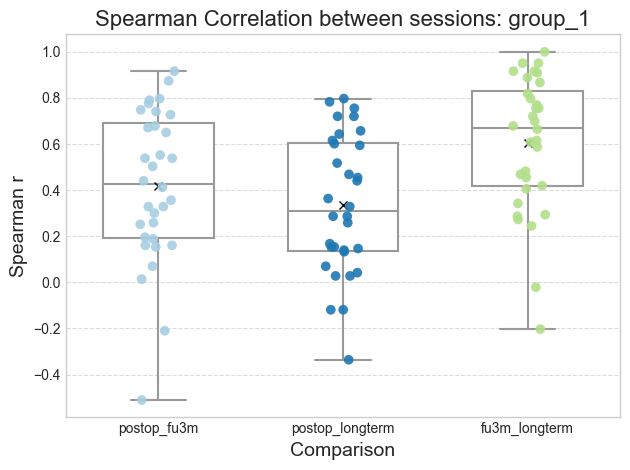

In [292]:
fig = plot_boxplot_spearman_r_values(cohort="group_1", all_groups_together="yes")

In [293]:
def t_test_fisher_transformed_correlation_coeff(cohort: str, all_groups_together: str):
    """
    Calculate the t-test of the fisher transformed correlation coefficients

    Input:
        - fooof_spectrum: "periodic_spectrum"
        - fooof_version: "v2"
        - all_groups_together: "yes" or "no"    -> "yes" will calculate the beta correlation of all LFPs of each subject
                                                -> "no" will calculate the beta correlation of each LFP group seperately of each subject



    """
    results_path = find_folders.get_local_path(folder="GroupResults")
    figures_path = find_folders.get_local_path(folder="GroupFigures")

    # store result in a dictionary
    t_test_results = {}
    all_groups_yes_no = {"yes": "all_LFPs", "no": "each_LFP_group"}

    # load the data
    spearman_result = fooof_bip_channel_groups_beta_spearman(cohort=cohort, all_groups_together=all_groups_together)
    spearman_result_df = spearman_result["spearman_result_df"]

    # get the fisher transformed correlation coefficients
    if cohort in ["group_3", "all_included"]:
        filter_comparisons = [
            "fu3m_postop",
            "fu12m_postop",
            "fu18or24m_postop",
            "fu12m_fu3m",
            "fu18or24m_fu3m",
            "fu18or24m_fu12m",
        ]
    
    elif cohort == "group_2":
        filter_comparisons = [
            "fu3m_fu12m",
            "fu3m_fu18or24m",
            "fu12m_fu18or24m",
        ]
    
    elif cohort == "group_1":
        filter_comparisons = [
            "postop_fu3m",
            "postop_longterm",
            "fu3m_longterm",
        ]

    # filter from dataframe only the comparisons that are needed for the t-test
    spearman_result_df = spearman_result_df[spearman_result_df["comparison"].isin(filter_comparisons)]

    # Create a 6x6 matrix filled with zeros
    comparison_matrix = np.zeros((len(filter_comparisons), len(filter_comparisons)))

    # Populate the matrix with comparison values
    for i in range(len(filter_comparisons)):
        for j in range(len(filter_comparisons)):
            if i != j:
                # Compare values and update the matrix
                # get the fisher transformed correlation coefficients for i and j
                fisher_i = spearman_result_df[spearman_result_df["comparison"] == filter_comparisons[i]]
                fisher_i = fisher_i["fisher_transformation_spearman_r"].values[0]

                fisher_j = spearman_result_df[spearman_result_df["comparison"] == filter_comparisons[j]]
                fisher_j = fisher_j["fisher_transformation_spearman_r"].values[0]

                # perform a t-test on the transformed correlation coefficients
                statistic, p_val = stats.ttest_ind(fisher_i, fisher_j)

                # store the p-value in the matrix
                comparison_matrix[i, j] = p_val

                # and store the statistic and p_val in a dictionary
                t_test_results[f"{filter_comparisons[i]}_vs_{filter_comparisons[j]}"] = [
                    filter_comparisons[i],
                    filter_comparisons[j],
                    statistic,
                    p_val,
                ]

            elif i == j:
                comparison_matrix[i, j] = 1

    # write Dataframe from dictionary
    t_test_results_df = pd.DataFrame(t_test_results)
    t_test_results_df.rename(index={0: "comparison_1", 1: "comparison_2", 2: "statistic", 3: "p-value"}, inplace=True)
    t_test_results_df = t_test_results_df.transpose()

    # save as Excel
    t_test_results_df.to_excel(
        os.path.join(
            results_path,
            f"revision_bipolar_LFPs_Spearman_correlations_t-test_fisher_transformed_{cohort}_{all_groups_yes_no[all_groups_together]}.xlsx",
        ),
        sheet_name="t-test_fisher_transformed",
        index=False,
    )

    # plot the matrix in a heatmap
    fig, ax = plt.subplots()

    heatmap = ax.pcolor(comparison_matrix, cmap=plt.cm.YlOrRd)

    # Set the x and y ticks to show the indices of the matrix
    ax.set_xticks(np.arange(comparison_matrix.shape[1]) + 0.5, minor=False)
    ax.set_yticks(np.arange(comparison_matrix.shape[0]) + 0.5, minor=False)

    # Set the tick labels to show the values of the matrix
    ax.set_xticklabels(filter_comparisons, minor=False, rotation=45)
    ax.set_yticklabels(filter_comparisons, minor=False)

    # Add a colorbar to the right of the heatmap
    cbar = plt.colorbar(heatmap)
    cbar.set_label("p-value")

    # Add the cell values to the heatmap
    for i in range(comparison_matrix.shape[0]):
        for j in range(comparison_matrix.shape[1]):
            plt.text(
                j + 0.5, i + 0.5, str("{: .2f}".format(comparison_matrix[i, j])), ha='center', va='center'
            )  # only show 2 numbers after the comma of a float

    # Add a title
    plt.title(f"t-test of fisher transformed Spearman correlation coefficients \nbipolar LFPs")

    fig.tight_layout()

    helpers.save_fig_png_and_svg(
        path=figures_path,
        filename=f"revision_t-test_fisher_transformed_Spearman_coeff_bipolar_{cohort}_{all_groups_yes_no[all_groups_together]}",
        figure=fig,
    )

    return t_test_results_df


file:  revision_group_1_bipolar_LFPs_beta_correlations_per_stn.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results
Figures revision_t-test_fisher_transformed_Spearman_coeff_bipolar_group_1_all_LFPs.svg and revision_t-test_fisher_transformed_Spearman_coeff_bipolar_group_1_all_LFPs.png 
were written in: /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/figures.


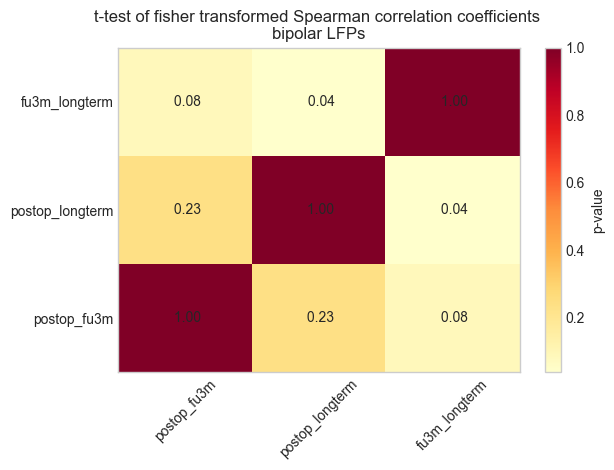

In [294]:
t_test = t_test_fisher_transformed_correlation_coeff(cohort="group_1", all_groups_together="yes")

In [295]:
t_test

,comparison_1,comparison_2,statistic,p-value
postop_fu3m_vs_postop_longterm,postop_fu3m,postop_longterm,1.199237,0.234999
postop_fu3m_vs_fu3m_longterm,postop_fu3m,fu3m_longterm,-1.757721,0.083731
postop_longterm_vs_postop_fu3m,postop_longterm,postop_fu3m,-1.199237,0.234999
postop_longterm_vs_fu3m_longterm,postop_longterm,fu3m_longterm,-2.118934,0.038109
fu3m_longterm_vs_postop_fu3m,fu3m_longterm,postop_fu3m,1.757721,0.083731
fu3m_longterm_vs_postop_longterm,fu3m_longterm,postop_longterm,2.118934,0.038109
